<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/stage_01_intraday_data_preparation/stage_01_intraday_data_preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage 01 — Intraday data preparation**

```
S01_intraday_data_preparation.ipynb
```

# **Resumen**

Esta notebook realiza la **preparación inicial del dataset intradía del MNQ (Micro E-mini Nasdaq 100)**.  
El objetivo es construir un dataset limpio, consistente y estructurado que servirá como base para la ingeniería de factores y el entrenamiento de modelos.

0. **Configuración del entorno**
   - Clonado del repositorio y montaje de Google Drive.
   - Instalación e importación de librerías necesarias.

1. **Fuente de datos**
   - Datos históricos intradía del MNQ (OHLCV, frecuencia de 1 minuto) exportados desde NinjaTrader.
   - Archivos originales en formato `.txt`, en zona horaria UTC.

2. **Generación del dataset**
   - Unificación de todos los archivos `.txt` en un único DataFrame.
   - Asignación de nombres de columnas: `open`, `high`, `low`, `close`, `volume`.
   - Conversión de la columna `datetime` a índice temporal.

3. **Filtrado**
   - Conserva solo **días hábiles bursátiles** (se eliminan fines de semana y feriados de mercado de EE.UU.).
   - Conversión de marcas de tiempo de **UTC → US/Eastern**.
   - Filtrado de **horario de mercado** (09:30–16:00) más pre-market (desde 08:30).

4. **Validación de registros diarios**
   - Verificación de que cada día contenga la cantidad esperada de registros minuto a minuto.
   - Detección y eliminación de días incompletos o con irregularidades.

5. **Chequeo de continuidad temporal**
   - Confirmación de que los datos intradía estén en intervalos consecutivos de 1 minuto, sin gaps.

6. **Dataset final**
   - Guardado del dataset limpio en formato `.parquet` dentro de Google Drive.

---

**Resultado:** Un dataset intradía del MNQ completamente limpio y estandarizado, listo para la ingeniería de factores y el modelado.

## **Configuración del Entorno**

### **Importación de librerías**

In [19]:
from __future__ import annotations  # permite type hints modernos (Python < 3.11)

# Utilidades generales
from datetime import datetime, timedelta
from io import StringIO
from pathlib import Path
import glob
import json
import os
import warnings

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

warnings.filterwarnings("ignore")

# Manejo y procesamiento de datos
import pandas as pd
from tabulate import tabulate

# Calendario de mercados y requests
import pandas_market_calendars as mcal
import requests

import mplfinance as mpf

### **Rutas de archivos**

In [20]:
from pathlib import Path

# Buscar la raíz del proyecto
PROJECT_ROOT = Path.cwd()

while PROJECT_ROOT.name != "neural_profit_local":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\heguu\OneDrive\Escritorio\neural_profit_local


### **Función para revisar información de dataset**

In [21]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import pandas as pd


def mnq_dataset_info(
    df: pd.DataFrame,
    *,
    name: str = "mnq_raw",
    tz_assume_if_naive: Optional[str] = None,  # ej: "UTC" o "America/New_York"
    day_def: str = "calendar",  # "calendar" (fecha calendario) o "trading" (días con datos)
) -> Dict[str, Any]:
    """
    Resume un dataset OHLCV con DatetimeIndex (ideal para mnq_raw).

    - Si el índice es tz-naive:
        - Si tz_assume_if_naive != None, lo localiza a esa tz.
        - Si no, reporta "tz-naive" (no se puede afirmar horario UTC).
    - Devuelve dict con métricas principales (y lo imprime bonito si se desea).
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError(f"{name}: se requiere DatetimeIndex, recibido: {type(df.index)}")

    idx = df.index

    # --- timezone / UTC info ---
    tzinfo = idx.tz
    if tzinfo is None:
        tz_status = "tz-naive (sin zona horaria)"
        if tz_assume_if_naive:
            idx = idx.tz_localize(tz_assume_if_naive)
            tzinfo = idx.tz
            tz_status = f"localizado como {tzinfo}"
    else:
        tz_status = f"{tzinfo}"

    # --- rango temporal ---
    ts_min = idx.min()
    ts_max = idx.max()

    first_day = ts_min.date()
    last_day = ts_max.date()

    # --- días ---
    if day_def == "calendar":
        total_days = (pd.Timestamp(last_day) - pd.Timestamp(first_day)).days + 1
    elif day_def == "trading":
        total_days = idx.normalize().nunique()
    else:
        raise ValueError("day_def debe ser 'calendar' o 'trading'")

    # --- columnas ---
    columns = list(df.columns)

    # --- checks útiles ---
    n_rows = len(df)
    n_cols = df.shape[1]
    n_missing = int(df.isna().sum().sum())
    missing_by_col = df.isna().sum().to_dict()
    dup_index = int(idx.duplicated().sum())
    is_monotonic = bool(idx.is_monotonic_increasing)

    # Frecuencia estimada (puede fallar si hay huecos grandes)
    freq = pd.infer_freq(idx[: min(50000, len(idx))])  # muestra grande pero acotada

    # Cobertura por día (min/max de hora del día, en tz del índice)
    # (Útil para ver si es 24/7 o horario de sesión)
    tod = pd.Series(idx.time)
    # Convertimos time a minutos del día para resumen robusto
    tod_minutes = pd.Series([t.hour * 60 + t.minute for t in tod])
    typical_minute_min = int(tod_minutes.min())
    typical_minute_max = int(tod_minutes.max())

    # Rango promedio de filas por día (sólo días con datos)
    rows_per_day = df.groupby(idx.normalize()).size()
    rows_per_day_stats = {
        "days_with_data": int(rows_per_day.shape[0]),
        "rows_per_day_min": int(rows_per_day.min()),
        "rows_per_day_p50": float(rows_per_day.median()),
        "rows_per_day_max": int(rows_per_day.max()),
    }

    # Si hay tz, también mostramos rango en UTC
    if tzinfo is not None:
        ts_min_utc = ts_min.tz_convert("UTC")
        ts_max_utc = ts_max.tz_convert("UTC")
        utc_range = (str(ts_min_utc), str(ts_max_utc))
        utc_note = "El índice está tz-aware; el horario UTC es inequívoco."
    else:
        utc_range = None
        utc_note = "El índice es tz-naive; no se puede asegurar si está en UTC sin suposiciones."

    info: Dict[str, Any] = {
        "name": name,
        "shape": (n_rows, n_cols),
        "columns": columns,
        "index_type": type(df.index).__name__,
        "index_tz": tz_status,
        "utc_note": utc_note,
        "datetime_min": str(ts_min),
        "datetime_max": str(ts_max),
        "first_day": str(first_day),
        "last_day": str(last_day),
        "total_days": int(total_days),
        "day_definition": day_def,
        "utc_range_if_applicable": utc_range,
        "is_index_monotonic_increasing": is_monotonic,
        "duplicated_timestamps_in_index": dup_index,
        "inferred_freq_sample": freq,
        "missing_total_cells": n_missing,
        "missing_by_col": missing_by_col,
        "rows_per_day_stats": rows_per_day_stats,
        "time_of_day_minutes_range": {
            "min_minute_of_day": typical_minute_min,
            "max_minute_of_day": typical_minute_max,
        },
    }
    return info


def print_mnq_dataset_info(info: Dict[str, Any]) -> None:
    """Imprime el dict de mnq_dataset_info de forma ordenada."""
    print(f"Dataset: {info['name']}")
    print(f"Shape: {info['shape']}")
    print(f"Columns: {info['columns']}")
    print(f"Index: {info['index_type']} | TZ: {info['index_tz']}")
    print(f"Datetime min/max: {info['datetime_min']}  ->  {info['datetime_max']}")
    print(f"First/Last day: {info['first_day']}  ->  {info['last_day']}")
    print(f"Total days ({info['day_definition']}): {info['total_days']}")
    #print(f"Inferred freq (sample): {info['inferred_freq_sample']}")
    #print(f"Index monotonic increasing: {info['is_index_monotonic_increasing']}")
    #print(f"Duplicated timestamps in index: {info['duplicated_timestamps_in_index']}")
    #print(f"Missing total cells: {info['missing_total_cells']}")
    #print(f"Missing by col: {info['missing_by_col']}")
    #print(f"Rows/day stats: {info['rows_per_day_stats']}")
    print(f"Time-of-day range (minutes): {info['time_of_day_minutes_range']}")
    print(f"UTC note: {info['utc_note']}")
    if info["utc_range_if_applicable"] is not None:
        print(f"UTC range: {info['utc_range_if_applicable'][0]}  ->  {info['utc_range_if_applicable'][1]}")

# **1. Carga del dataset crudo `mnq_raw`**

In [22]:
# ============================================================
# Paths RAW
# ============================================================

RAW_PATH = PROJECT_ROOT / "data" / "01_raw"
RAW_PATH.mkdir(parents=True, exist_ok=True)

RAW_JSON_PATH = RAW_PATH / "mnq_raw_summary.json"
RAW_PARQUET_PATH = RAW_PATH / "mnq_raw.parquet"

In [23]:
# ============================================================
# Cargar dataset RAW en formato Parquet
# ============================================================

def load_raw_parquet(dataset_path=RAW_PARQUET_PATH):
    dataset_path = Path(dataset_path)

    if not dataset_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo Parquet: {dataset_path}")

    print(f"Archivo Parquet encontrado. Cargando dataset desde: {dataset_path}")

    mnq_raw = pd.read_parquet(dataset_path)

    return mnq_raw


# ============================================================
# Cargar resumen RAW en formato JSON
# ============================================================

def load_raw_json(json_path=RAW_JSON_PATH):
    json_path = Path(json_path)

    if not json_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo JSON: {json_path}")

    print(f"Archivo JSON encontrado. Cargando resumen desde: {json_path}")

    with json_path.open("r", encoding="utf-8") as f:
        mnq_raw_summary = json.load(f)

    return mnq_raw_summary

In [24]:
mnq_raw = load_raw_parquet()
mnq_raw

mnq_raw_summary = load_raw_json()
mnq_raw_summary

Archivo Parquet encontrado. Cargando dataset desde: c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\01_raw\mnq_raw.parquet
Archivo JSON encontrado. Cargando resumen desde: c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\01_raw\mnq_raw_summary.json


{'name': 'mnq_raw',
 'shape': [2172640, 6],
 'columns': ['open', 'high', 'low', 'close', 'volume', 'contract'],
 'index_type': 'DatetimeIndex',
 'index_tz': 'localizado como UTC',
 'utc_note': 'El índice está tz-aware; el horario UTC es inequívoco.',
 'datetime_min': '2019-12-23 03:01:00+00:00',
 'datetime_max': '2026-04-17 20:18:00+00:00',
 'first_day': '2019-12-23',
 'last_day': '2026-04-17',
 'total_days': 2005,
 'day_definition': 'trading',
 'utc_range_if_applicable': ['2019-12-23 03:01:00+00:00',
  '2026-04-17 20:18:00+00:00'],
 'is_index_monotonic_increasing': True,
 'duplicated_timestamps_in_index': 0,
 'inferred_freq_sample': None,
 'missing_total_cells': 0,
 'missing_by_col': {'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'volume': 0,
  'contract': 0},
 'rows_per_day_stats': {'days_with_data': 2005,
  'rows_per_day_min': 1,
  'rows_per_day_p50': 1365.0,
  'rows_per_day_max': 1382},
 'time_of_day_minutes_range': {'min_minute_of_day': 0,
  'max_minute_of_day': 1439}}

# **2. Determinación de la zona horaria del dataset**

In [25]:
# =============================================================================
# INSPECCIÓN DE UNA JORNADA DE TRADING
# =============================================================================
# Objetivo:
# Seleccionar una sesión específica del dataset para analizar la estructura
# temporal de los registros, verificar horarios de inicio y fin, cantidad de
# barras disponibles y consistencia cronológica de la información.
#
# Procedimiento:
# 1. Convertir el índice a formato datetime.
# 2. Ordenar los registros cronológicamente.
# 3. Seleccionar una fecha específica para inspección.
# 4. Extraer todos los registros correspondientes a esa jornada.
# 5. Visualizar la sesión completa para su análisis.
# =============================================================================

# Convertir el índice a tipo datetime
mnq_raw.index = pd.to_datetime(mnq_raw.index)

# Asegurar orden cronológico ascendente
mnq_raw = mnq_raw.sort_index()

# Fecha seleccionada para análisis
analysis_day = "2023-10-02"

# Extraer todos los registros de la jornada seleccionada
df_day = mnq_raw.loc[analysis_day]

# Mostrar la sesión completa
df_day

,open,high,low,close,volume,contract
datetime,,,,,,
2023-10-02 00:00:00,14955.25,14955.75,14952.00,14953.00,299,Z23
2023-10-02 00:01:00,14953.00,14957.75,14952.00,14952.00,598,Z23
2023-10-02 00:02:00,14952.75,14954.50,14951.00,14952.75,280,Z23
2023-10-02 00:03:00,14952.50,14954.50,14951.50,14953.25,89,Z23
2023-10-02 00:04:00,14953.00,14956.50,14953.00,14956.00,132,Z23
...,...,...,...,...,...,...
2023-10-02 23:55:00,14993.50,14996.00,14993.00,14994.00,77,Z23
2023-10-02 23:56:00,14994.00,14996.25,14992.75,14993.00,122,Z23
2023-10-02 23:57:00,14993.25,14994.75,14992.50,14992.75,47,Z23


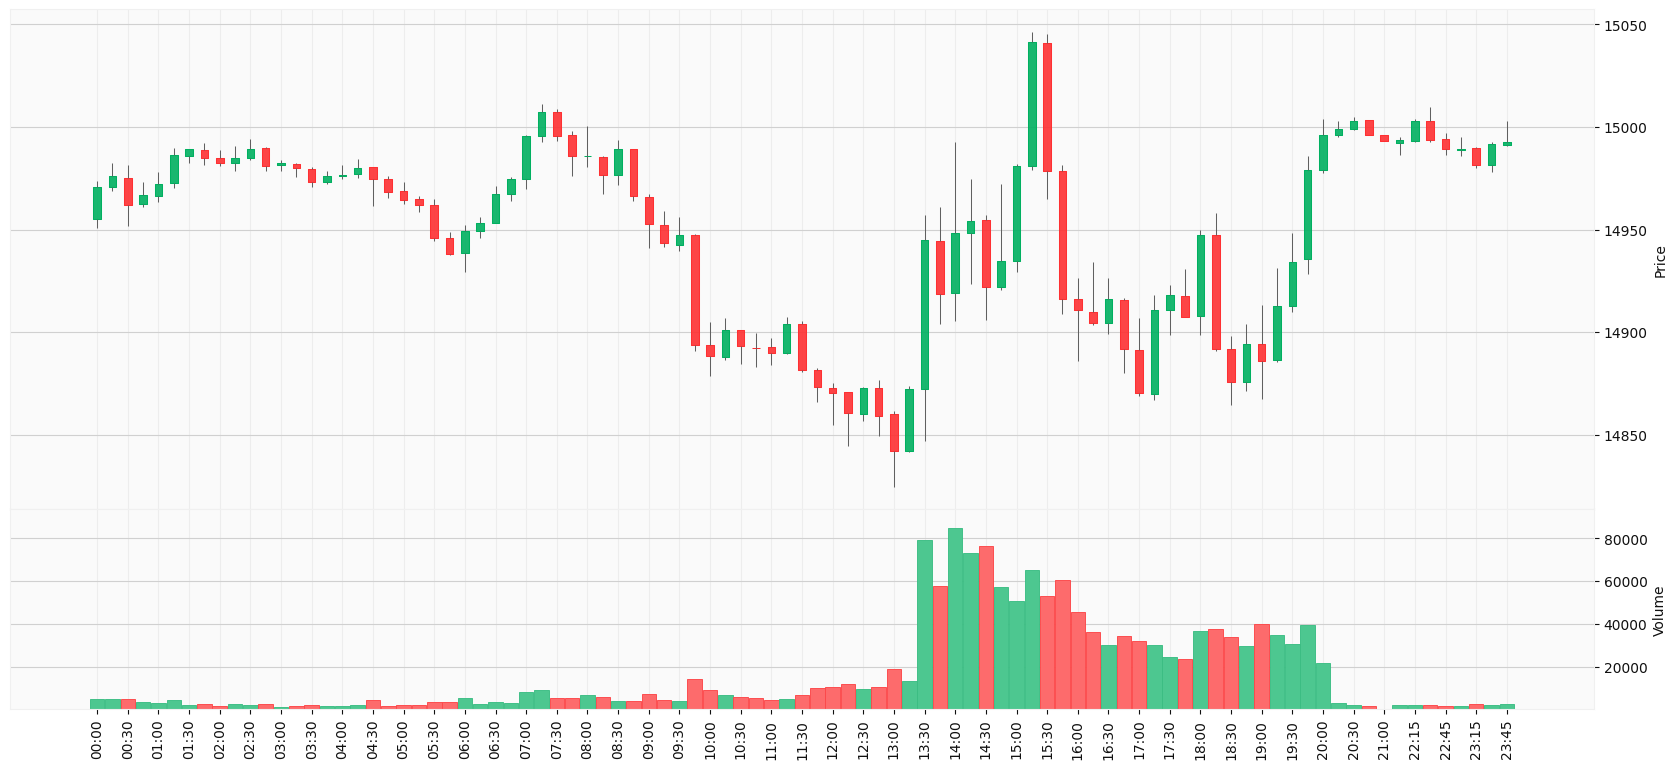

In [26]:
# =============================================================================
# VISUALIZACIÓN DE UNA JORNADA EN VELAS DE 15 MINUTOS
# =============================================================================
# Objetivo:
# Transformar los datos intradía de la jornada seleccionada a velas de 15 minutos
# y visualizar el comportamiento del precio junto con el volumen.
#
# Requisitos:
# - df_day debe tener índice datetime.
# - df_day debe contener columnas: open, high, low, close, volume.
# =============================================================================

import warnings
import numpy as np
import matplotlib.pyplot as plt
import mplfinance as mpf

# =============================================================================
# 1. RESAMPLEO DE DATOS A 15 MINUTOS
# =============================================================================
# Se agregan las barras originales para construir velas OHLCV de 15 minutos:
# - open   : primer precio del intervalo
# - high   : máximo del intervalo
# - low    : mínimo del intervalo
# - close  : último precio del intervalo
# - volume : suma del volumen del intervalo

df_15min = (
    df_day
    .resample("15min")
    .agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum",
    })
    .dropna()
)

# mplfinance requiere nombres de columnas con formato estándar
ohlcv_15min = df_15min.rename(columns={
    "open": "Open",
    "high": "High",
    "low": "Low",
    "close": "Close",
    "volume": "Volume",
})

# =============================================================================
# 2. GRÁFICO DE VELAS Y VOLUMEN
# =============================================================================
# mplfinance genera el gráfico de candlesticks y el panel inferior de volumen.
# Se silencian warnings visuales, por ejemplo advertencias por exceso de ticks.

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    fig, axes = mpf.plot(
        ohlcv_15min,
        type="candle",
        volume=True,
        figsize=(22, 10),
        style="yahoo",
        xrotation=0,
        returnfig=True,
    )

# =============================================================================
# 3. FORMATO DEL EJE X
# =============================================================================
# mplfinance usa posiciones numéricas internas para representar cada vela.
# Por eso se generan manualmente las posiciones y etiquetas de hora.
#
# Como las velas son de 15 minutos:
# - cada barra representa 15 minutos
# - cada 2 barras representa 30 minutos

ax_price = axes[0]
ax_volume = axes[2] if len(axes) > 2 else axes[1]

n_bars = len(ohlcv_15min)
x_positions = np.arange(n_bars)

tick_step = 2  # etiqueta cada 30 minutos
tick_positions = x_positions[::tick_step]
tick_labels = [
    timestamp.strftime("%H:%M")
    for timestamp in ohlcv_15min.index[::tick_step]
]

# Aplicar etiquetas de hora y grilla vertical a ambos paneles
for ax in (ax_price, ax_volume):
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, ha="center")
    ax.grid(True, which="major", axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

El índice temporal del dataset no contiene información explícita de zona horaria. Sin embargo, el comportamiento intradía del volumen permite inferirla.

Se observa un incremento significativo de actividad alrededor de las 13:30, seguido por el período de mayor negociación entre las 13:30 y las 15:30.

Este patrón coincide con la apertura y primeras horas de la sesión regular (RTH) del mercado estadounidense.

Dado que durante octubre la apertura del Nasdaq ocurre a las 09:30 hora de Nueva York (UTC-4), dicha apertura corresponde a las 13:30 UTC.

La coincidencia entre la apertura esperada y el incremento observado de volumen sugiere que los timestamps del dataset están expresados en horario UTC.

**Conclusión**

- El dataset mnq_raw se encuentra en: **UTC (UTC+00:00)**

In [27]:
# =============================================================================
# RESUMEN GENERAL DEL DATASET
# =============================================================================
# Objetivo:
# Generar un reporte descriptivo del dataset para verificar sus principales
# características estructurales y temporales antes de continuar con el
# proceso de preparación de datos.
#
# La función analiza, entre otros aspectos:
# - Dimensión del dataset (filas y columnas).
# - Rango temporal cubierto.
# - Tipo de índice utilizado.
# - Zona horaria asociada a los timestamps.
# - Cobertura temporal del histórico.
# - Cantidad de días con información disponible.
# - Rango horario cubierto por los registros.
#
# Parámetros:
# - name:
#     Nombre descriptivo que aparecerá en el reporte.
#
# - tz_assume_if_naive:
#     Si el índice no tiene zona horaria explícita (tz-naive),
#     se asume UTC para poder realizar el análisis temporal.
#
# - day_def="trading":
#     Cuenta únicamente los días que contienen registros,
#     ignorando fines de semana o jornadas sin actividad.
# =============================================================================

info = mnq_dataset_info(
    mnq_raw,
    name="mnq_raw",
    tz_assume_if_naive="UTC",
    day_def="trading"
)

# Mostrar reporte resumido del dataset
print_mnq_dataset_info(info)

Dataset: mnq_raw
Shape: (2172640, 6)
Columns: ['open', 'high', 'low', 'close', 'volume', 'contract']
Index: DatetimeIndex | TZ: localizado como UTC
Datetime min/max: 2019-12-23 03:01:00+00:00  ->  2026-04-17 20:18:00+00:00
First/Last day: 2019-12-23  ->  2026-04-17
Total days (trading): 2005
Time-of-day range (minutes): {'min_minute_of_day': 0, 'max_minute_of_day': 1439}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2019-12-23 03:01:00+00:00  ->  2026-04-17 20:18:00+00:00


## **2.1. Verificaciones**

In [28]:
# =============================================================================
# 2.1. VERIFICACIÓN DE DÍAS DISPONIBLES EN EL DATASET RAW
# =============================================================================
# Objetivo:
# Contar la cantidad de días distintos presentes en el dataset.
#
# Esta verificación permite conocer la cobertura temporal real del histórico,
# considerando únicamente los días que contienen registros.

def count_total_days(df: pd.DataFrame) -> int:
    """
    Cuenta la cantidad total de días distintos presentes en un DataFrame
    con índice de tipo DatetimeIndex.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El DataFrame debe tener un DatetimeIndex.")

    total_days = df.index.normalize().nunique()

    return int(total_days)


total_days_raw = count_total_days(mnq_raw)

print(f"Total days (RAW): {total_days_raw}")

Total days (RAW): 2005


In [29]:
# =============================================================================
# 2.X VERIFICACIÓN DE REGISTROS COMPLETAMENTE DUPLICADOS
# =============================================================================
# Objetivo:
# Detectar filas idénticas considerando tanto el timestamp como los valores OHLCV.
#
# Para esto se convierte temporalmente el índice datetime en una columna,
# de manera que la comparación incluya:
# - datetime
# - open
# - high
# - low
# - close
# - volume
#
# Esta verificación permite identificar duplicados exactos generados, por ejemplo,
# por una carga repetida de datos históricos.

df_raw_with_datetime = mnq_raw.reset_index()

duplicated_full_rows_mask = df_raw_with_datetime.duplicated(keep=False)

df_duplicated_full_rows = df_raw_with_datetime[duplicated_full_rows_mask]

print(
    "Total registros idénticos incluyendo repeticiones: "
    f"{df_duplicated_full_rows.shape[0]}"
)

print(
    "Total registros únicos duplicados: "
    f"{df_duplicated_full_rows.drop_duplicates().shape[0]}"
)

df_duplicated_full_rows.head()

Total registros idénticos incluyendo repeticiones: 0
Total registros únicos duplicados: 0


,datetime,open,high,low,close,volume,contract


In [30]:
# =============================================================================
# 2.X VERIFICACIÓN DE TIMESTAMPS DUPLICADOS
# =============================================================================
# Objetivo:
# Identificar timestamps repetidos en el índice, independientemente de si los
# valores OHLCV son iguales o distintos.
#
# Esta verificación es más amplia que la anterior:
# - Puede detectar duplicados exactos.
# - Puede detectar timestamps repetidos con valores diferentes.

duplicated_timestamp_mask = mnq_raw.index.duplicated(keep=False)

df_duplicated_timestamps = mnq_raw[duplicated_timestamp_mask]

print(f"Timestamps duplicados: {duplicated_timestamp_mask.sum()}")

df_duplicated_timestamps.head()

Timestamps duplicados: 0


,open,high,low,close,volume,contract
datetime,,,,,,


In [31]:
# =============================================================================
# 2.X VERIFICACIÓN DE CONFLICTOS REALES EN TIMESTAMPS DUPLICADOS
# =============================================================================
# Objetivo:
# Detectar timestamps duplicados que presentan valores distintos de cierre.
#
# Un timestamp duplicado no siempre implica un conflicto real:
# - Si todas las filas repetidas son idénticas, puede tratarse de duplicación exacta.
# - Si el mismo timestamp tiene precios distintos, existe una inconsistencia
#   real en los datos.
#
# En esta primera revisión se usa la columna close como referencia principal
# para detectar conflictos.

df_raw_with_datetime = mnq_raw.reset_index()

timestamp_close_conflicts = (
    df_raw_with_datetime
    .groupby("datetime")
    .agg(n_unique_close=("close", "nunique"))
)

timestamp_close_conflicts = timestamp_close_conflicts[
    timestamp_close_conflicts["n_unique_close"] > 1
]

print(f"Timestamps con conflicto real: {len(timestamp_close_conflicts)}")

timestamp_close_conflicts.head()

Timestamps con conflicto real: 0


,n_unique_close
datetime,


# **3. Filtrado de días no hábiles y horario bursátil**

## **3.1. Filtrado de fines de semana y feriados bursátiles estadounidenses**

Es necesario filtrar del conjunto de datos aquellas filas correspondientes a sábados, domingos y feriados bursátiles. Para ello, se utilizará la librería pandas_market_calendars, que permite identificar los días hábiles de operación según el calendario oficial del NASDAQ.

La función implementada filtra un DataFrame con índice de tipo DatetimeIndex, conservando únicamente aquellas filas cuya fecha coincida con un día hábil del mercado. La marca temporal completa (fecha y hora) se mantiene sin modificaciones.

In [32]:
mnq_raw

,open,high,low,close,volume,contract
datetime,,,,,,
2019-12-23 03:01:00,8718.50,8718.75,8718.50,8718.50,9,H20
2019-12-23 03:02:00,8718.25,8718.25,8718.00,8718.25,14,H20
2019-12-23 03:03:00,8718.25,8718.50,8718.00,8718.25,74,H20
2019-12-23 03:04:00,8718.25,8719.00,8718.25,8718.50,10,H20
2019-12-23 03:05:00,8718.50,8719.00,8718.50,8719.00,6,H20
...,...,...,...,...,...,...
2026-04-17 20:14:00,26835.50,26844.50,26835.50,26839.25,1120,M26
2026-04-17 20:15:00,26839.50,26842.25,26837.75,26840.25,605,M26
2026-04-17 20:16:00,26840.75,26841.75,26835.75,26841.25,615,M26


In [33]:
# =============================================================================
# FILTRADO DE FINES DE SEMANA Y FERIADOS BURSÁTILES
# =============================================================================
# Objetivo:
# Conservar únicamente los registros correspondientes a jornadas oficiales
# de negociación del mercado NASDAQ.
#
# Aunque los contratos de futuros operan prácticamente las 24 horas durante
# los días hábiles, existen períodos sin negociación asociados a:
#
# - Fines de semana.
# - Feriados oficiales del mercado estadounidense.
# - Cierres extraordinarios definidos por la bolsa.
#
# Para garantizar la consistencia temporal del dataset, se utiliza el
# calendario oficial del NASDAQ provisto por pandas_market_calendars.
#
# Procedimiento:
# 1. Obtener el calendario oficial del NASDAQ.
# 2. Determinar el rango temporal cubierto por el dataset.
# 3. Generar la lista de días hábiles de negociación.
# 4. Mantener únicamente los registros cuyas fechas pertenezcan
#    a jornadas válidas de trading.
# =============================================================================

def filter_nasdaq_trading_days(df: pd.DataFrame) -> pd.DataFrame:
    """
    Conserva únicamente las filas pertenecientes a días oficiales
    de negociación del calendario NASDAQ.
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El DataFrame debe tener un DatetimeIndex.")

    nasdaq_calendar = mcal.get_calendar("NASDAQ")

    start_date = df.index.min().date()
    end_date = df.index.max().date()

    trading_days = nasdaq_calendar.schedule(
        start_date=start_date,
        end_date=end_date
    ).index.date

    # Convertir también el índice del dataset a date para comparar correctamente
    mask_trading_days = pd.Series(
        df.index.date,
        index=df.index
    ).isin(trading_days)

    filtered_df = df.loc[mask_trading_days].copy()

    return filtered_df


In [34]:
# =============================================================================
# APLICACIÓN DEL FILTRADO DE DÍAS HÁBILES DE TRADING
# =============================================================================
# Objetivo:
# Eliminar del dataset todas las observaciones correspondientes a fechas que
# no forman parte del calendario oficial de negociación del NASDAQ.
#
# Esto permite trabajar únicamente con jornadas válidas de mercado,
# excluyendo:
# - Fines de semana.
# - Feriados bursátiles estadounidenses.
# - Días sin actividad oficial de trading.
#
# El resultado se almacena en un nuevo dataset denominado mnq_intraday,
# que será utilizado en las siguientes etapas del análisis.
# =============================================================================

# Conservar únicamente registros pertenecientes a jornadas oficiales de trading
mnq_intraday = filter_nasdaq_trading_days(mnq_raw)

# =============================================================================
# RESUMEN DEL DATASET FILTRADO
# =============================================================================
# Contar la cantidad de días de trading presentes después del filtrado.
#
# Este valor representa el número de jornadas con actividad bursátil
# incluidas en el dataset depurado.
# =============================================================================

trading_days_count = count_total_days(mnq_intraday)

print(f"Trading days: {trading_days_count}")
print(f"Rows after filter: {len(mnq_intraday)}")

Trading days: 1568
Rows after filter: 2092715


## **3.2. Estandarización temporal a America/New_York**

Una vez determinada la zona horaria original del dataset (UTC), resulta necesario proceder a su estandarización al horario operativo del mercado de referencia, es decir, America/New_York.

Este paso no responde a una cuestión estética ni de conveniencia visual, sino a una necesidad estructural dentro del pipeline de investigación y modelado.

El contrato MNQ está intrínsecamente vinculado a la dinámica del mercado estadounidense, cuya sesión regular se desarrolla entre las 09:30 y 16:00 hora de Nueva York. Trabajar en UTC desplaza estas referencias temporales y puede generar inconsistencias en la definición de ventanas operativas, en la construcción de variables intradía y en la interpretación de resultados.

Asimismo, la correcta alineación horaria es fundamental para:

Garantizar coherencia con la sesión real del mercado.

Definir adecuadamente variables dependientes del tiempo (por ejemplo, minute_of_day, flags de RTH, ventanas de ejecución).

Manejar correctamente los cambios de horario por Daylight Saving Time (DST).

Preservar el principio de consistencia temporal en backtesting.

Asegurar interpretabilidad y robustez en el análisis de desempeño del modelo.

En consecuencia, la conversión explícita del índice temporal a America/New_York constituye un paso metodológico necesario para mantener la integridad temporal del dataset y la validez de los resultados posteriores.

In [35]:
# =============================================================================
# CONVERSIÓN DE ZONA HORARIA DEL DATASET
# =============================================================================
# Objetivo:
# Convertir los timestamps del dataset desde una zona horaria de origen
# hacia una zona horaria de destino, preservando correctamente el instante
# temporal representado por cada registro.
#
# Contexto:
# En las etapas anteriores se determinó que los timestamps del dataset se
# encuentran expresados en UTC. Sin embargo, para ciertos análisis resulta
# más conveniente trabajar en horario del mercado estadounidense
# (America/New_York).
#
# La función:
#
# 1. Realiza una copia del DataFrame original.
# 2. Verifica que el índice sea un DatetimeIndex.
# 3. Si el índice no posee zona horaria (tz-naive), lo localiza en la
#    zona horaria especificada por 'from_tz'.
# 4. Convierte posteriormente los timestamps a la zona horaria de destino.
#
# Importante:
# - tz_localize() asigna una zona horaria a timestamps tz-naive.
# - tz_convert() transforma los timestamps entre zonas horarias
#   preservando el instante temporal real.
#
# El DataFrame original no es modificado.
# =============================================================================

def configure_timezone(
    df: pd.DataFrame,
    from_tz: str = "UTC",
    to_tz: str = "America/New_York"
) -> pd.DataFrame:
    """
    Localiza y convierte la zona horaria del índice temporal.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame indexado mediante DatetimeIndex.

    from_tz : str, default="UTC"
        Zona horaria asumida para índices tz-naive.

    to_tz : str, default="America/New_York"
        Zona horaria de destino.

    Retorna
    -------
    pandas.DataFrame
        Copia del DataFrame con el índice convertido
        a la zona horaria especificada.
    """

    # Trabajar sobre una copia para preservar el dataset original
    df = df.copy()

    # Verificar que el índice sea temporal
    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El índice debe ser DatetimeIndex.")

    # Si el índice no tiene zona horaria explícita,
    # asumir la zona indicada por from_tz
    if df.index.tz is None:
        df.index = df.index.tz_localize(from_tz)

    # Convertir a la zona horaria de destino
    df.index = df.index.tz_convert(to_tz)

    return df


In [36]:
# =============================================================================
# CONVERSIÓN DEL DATASET A HORARIO DE NUEVA YORK
# =============================================================================
# Objetivo:
# Transformar los timestamps del dataset desde UTC hacia la zona horaria
# oficial del mercado estadounidense (America/New_York).
#
# Esto facilita la interpretación de las sesiones de trading, ya que los
# horarios observados coincidirán directamente con:
#
# - Pre-market
# - Apertura regular (09:30)
# - Sesión regular
# - Cierre del mercado (16:00)
# - Post-market
#
# La conversión preserva el instante temporal real de cada registro;
# únicamente modifica su representación horaria.
# =============================================================================

# Convertir timestamps desde UTC hacia horario New York
mnq_intraday = configure_timezone(mnq_intraday)

# Verificar zona horaria resultante
print(mnq_intraday.index.tz)

America/New_York


In [37]:
# =============================================================================
# RESUMEN DEL DATASET TRAS LA CONVERSIÓN HORARIA
# =============================================================================
# Generar nuevamente el perfil descriptivo del dataset para verificar:
#
# - Cobertura temporal.
# - Tipo de índice.
# - Zona horaria actual.
# - Rango de fechas.
# - Cantidad de días de trading.
# - Cobertura horaria diaria.
#
# A diferencia del dataset original, ahora el índice ya posee una zona
# horaria explícita (tz-aware), por lo que no es necesario asumir UTC.
# =============================================================================

info = mnq_dataset_info(
    mnq_intraday,
    name="mnq_intraday",
    tz_assume_if_naive=None,
    day_def="trading"
)

print_mnq_dataset_info(info)

Dataset: mnq_intraday
Shape: (2092715, 6)
Columns: ['open', 'high', 'low', 'close', 'volume', 'contract']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2019-12-22 22:01:00-05:00  ->  2026-04-17 16:18:00-04:00
First/Last day: 2019-12-22  ->  2026-04-17
Total days (trading): 1910
Time-of-day range (minutes): {'min_minute_of_day': 0, 'max_minute_of_day': 1439}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2019-12-23 03:01:00+00:00  ->  2026-04-17 20:18:00+00:00


In [38]:
mnq_intraday

,open,high,low,close,volume,contract
datetime,,,,,,
2019-12-22 22:01:00-05:00,8718.50,8718.75,8718.50,8718.50,9,H20
2019-12-22 22:02:00-05:00,8718.25,8718.25,8718.00,8718.25,14,H20
2019-12-22 22:03:00-05:00,8718.25,8718.50,8718.00,8718.25,74,H20
2019-12-22 22:04:00-05:00,8718.25,8719.00,8718.25,8718.50,10,H20
2019-12-22 22:05:00-05:00,8718.50,8719.00,8718.50,8719.00,6,H20
...,...,...,...,...,...,...
2026-04-17 16:14:00-04:00,26835.50,26844.50,26835.50,26839.25,1120,M26
2026-04-17 16:15:00-04:00,26839.50,26842.25,26837.75,26840.25,605,M26
2026-04-17 16:16:00-04:00,26840.75,26841.75,26835.75,26841.25,615,M26


## **3.3. Filtrado de horario regular**

La siguiente función selecciona únicamente las muestras que se encuentran dentro del horario regular de operación bursátil del NASDAQ.

Filtra un DataFrame cuyo índice es de tipo DatetimeIndex, conservando solo aquellas filas cuya marca temporal se encuentre entre las 09:30 y 16:00 horas (US/Eastern), correspondientes al horario de negociación estándar en días hábiles de mercado.

Particularmente, decido agregar una hora de pre mercado, desde las 06:30AM.

In [39]:
# =============================================================================
# FILTRADO POR HORARIO DE NEGOCIACIÓN
# =============================================================================
# Objetivo:
# Conservar únicamente los registros que se encuentren dentro de un rango
# horario específico de negociación.
#
# Esta función permite aislar determinados períodos de mercado, por ejemplo:
#
# - Pre-market
# - Sesión regular (RTH)
# - Post-market
# - Horarios personalizados para análisis intradía
#
# Requisito:
# El índice del DataFrame debe encontrarse en la zona horaria adecuada
# (por ejemplo, America/New_York) antes de aplicar el filtrado.
#
# Ejemplos:
#
# Sesión regular NASDAQ:
#     09:30:00 - 16:00:00
#
# Pre-market:
#     04:00:00 - 09:29:59
#
# Horario extendido:
#     04:00:00 - 20:00:00
#
# La función utiliza el método between_time() de pandas, que filtra las
# observaciones según la hora del día, independientemente de la fecha.
# =============================================================================

def filter_nasdaq_trading_hours(
    df: pd.DataFrame,
    start_time: str,
    end_time: str
) -> pd.DataFrame:
    """
    Filtra un DataFrame para conservar únicamente las filas que se
    encuentren dentro de un rango horario determinado.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame indexado mediante DatetimeIndex.

    start_time : str
        Hora de inicio del período a conservar.
        Ejemplo: "09:30:00"

    end_time : str
        Hora de finalización del período a conservar.
        Ejemplo: "16:00:00"

    Retorna
    -------
    pandas.DataFrame
        Dataset filtrado dentro del rango horario especificado.
    """

    # Conservar únicamente registros comprendidos
    # entre la hora de inicio y la hora de cierre
    filtered_df = df.between_time(
        start_time,
        end_time
    )

    return filtered_df

In [40]:
# =============================================================================
# FILTRADO DE LA SESIÓN INTRADÍA DE INTERÉS
# =============================================================================
# Objetivo:
# Conservar únicamente los registros comprendidos entre las 04:30 y las
# 16:00 horas (America/New_York).
#
# Esta ventana incluye:
#
# - Pre-market.
# - Apertura regular del mercado.
# - Sesión regular (RTH).
#
# El objetivo es eliminar los períodos de muy baja actividad que ocurren
# durante la sesión overnight, concentrando el análisis en las horas con
# mayor liquidez y relevancia operativa.
# =============================================================================

# Conservar únicamente registros entre 04:30 y 16:00 (hora New York)
mnq_intraday = filter_nasdaq_trading_hours(
    mnq_intraday,
    "04:30:00",
    "16:00:00"
)

# =============================================================================
# RESUMEN DEL DATASET FILTRADO
# =============================================================================
# Verificar cuántos días de trading permanecen en el dataset luego del
# filtrado horario.
#
# Como únicamente se eliminaron registros fuera del rango horario definido,
# la cantidad de jornadas debería mantenerse prácticamente inalterada,
# salvo casos excepcionales de sesiones incompletas.
# =============================================================================

trading_session_days = count_total_days(mnq_intraday)

print(
    f"Trading session days (04:30:00 to 16:00:00): "
    f"{trading_session_days}"
)

# =============================================================================
# PERFIL DESCRIPTIVO DEL DATASET INTRADÍA
# =============================================================================
# Generar un nuevo resumen estadístico para verificar:
#
# - Cobertura temporal.
# - Zona horaria.
# - Cantidad de días de trading.
# - Rango horario efectivo del dataset.
#
# Este reporte permite confirmar que únicamente permanecen registros
# dentro de la ventana horaria seleccionada.
# =============================================================================

info_intraday = mnq_dataset_info(
    mnq_intraday,
    name="mnq_intraday",
    tz_assume_if_naive="America/New_York",
    day_def="trading"
)

print_mnq_dataset_info(info_intraday)

Trading session days (04:30:00 to 16:00:00): 1562
Dataset: mnq_intraday
Shape: (1064626, 6)
Columns: ['open', 'high', 'low', 'close', 'volume', 'contract']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2019-12-23 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2019-12-23  ->  2026-04-17
Total days (trading): 1562
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2019-12-23 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00


# **4. Análisis de registros diarios**

Es necesario verificar que todos los días del conjunto de datos contengan la misma cantidad de registros y que estos sean consecutivos, es decir, que no falte ningún minuto dentro de cada jornada.

La función analizar_registros_por_dia permite realizar este control sobre un DataFrame con índice de tipo datetime. La función contabiliza la cantidad de registros por día e imprime una tabla resumen que indica cuántos días presentan una determinada cantidad de registros. Esto resulta útil para identificar inconsistencias, como días incompletos o interrupciones en la frecuencia temporal esperada.

In [ ]:
# ANÁLISIS DE COBERTURA DIARIA DEL DATASET
# =============================================================================
# Objetivo:
# Evaluar la cantidad de registros disponibles en cada jornada de trading
# para identificar posibles días incompletos o con datos faltantes.
#
# Metodología:
# 1. Contar la cantidad de registros por día.
# 2. Identificar el tamaño típico de una jornada completa mediante la moda
#    (valor más frecuente).
# 3. Comparar cada jornada contra dicho valor de referencia.
# 4. Cuantificar cuántos días presentan una cobertura inferior a la esperada.
#
# Esta verificación permite detectar:
# - Jornadas incompletas.
# - Datos faltantes.
# - Problemas de captura o almacenamiento.
# - Sesiones afectadas por cierres anticipados.
#
# La función devuelve:
# - El conteo de registros por día.
# - La cantidad de registros esperada para una jornada completa.
# =============================================================================

def analyze_daily_record_counts(
    df: pd.DataFrame
) -> tuple[pd.Series, int]:
    """
    Analiza la cantidad de registros por jornada de trading.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame indexado mediante DatetimeIndex.

    Retorna
    -------
    tuple[pandas.Series, int]

        daily_counts:
            Cantidad de registros observados en cada día.

        full_day_records:
            Cantidad de registros correspondiente a una
            jornada completa (valor modal).
    """

    # Contar registros por día
    daily_counts = df.groupby(df.index.date).size()

    # Determinar el tamaño típico de una jornada completa
    # utilizando el valor más frecuente (moda)
    full_day_records = daily_counts.mode().iloc[0]

    print(
        f"Cantidad de registros en una jornada completa: "
        f"{full_day_records}"
    )

    # Calcular cuántas jornadas presentan menos registros
    # que una sesión completa
    total_days = len(daily_counts)

    incomplete_days = (
        daily_counts < full_day_records
    ).sum()

    incomplete_percentage = (
        incomplete_days / total_days
    ) * 100

    print(
        f"Días con menos de {full_day_records} registros: "
        f"{incomplete_days} de {total_days} "
        f"({incomplete_percentage:.2f}%)"
    )

    return daily_counts, full_day_records

In [ ]:
# ANÁLISIS DE COBERTURA POR JORNADA DE TRADING
# =============================================================================
# Objetivo:
# Evaluar la cantidad de registros disponibles en cada día del dataset
# intradía para identificar posibles jornadas incompletas.
#
# Resultados obtenidos:
#
# - daily_record_counts:
#     Serie que contiene la cantidad de registros observados en cada día.
#
# - full_day_record_count:
#     Cantidad de registros correspondiente a una jornada completa,
#     estimada mediante el valor más frecuente (moda).
#
# Esta información servirá posteriormente para:
# - Detectar días con datos faltantes.
# - Identificar sesiones incompletas.
# - Aplicar filtros de calidad al dataset.
# =============================================================================

daily_record_counts, full_day_record_count = analyze_daily_record_counts(
    mnq_intraday
)

Cantidad de registros en una jornada completa: 691
Días con menos de 691 registros: 80 de 1562 (5.12%)


Como podemos observar en la tabla, la gran mayoría de días tienen 691 muestras. Y representan más del 94% del total de los datos.


## **4.1. Filtrado de días incompletos**

La siguiente función encuentra los indices de las fechas con registros incompletos:

In [43]:
def find_incomplete_trading_dates(
    df: pd.DataFrame,
    expected_records: int,
    gap_minutes: int = 1,
) -> list[pd.Timestamp]:
    """
    Identifica los días que presentan menos registros de los esperados
    o irregularidades en la secuencia temporal de los datos.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con índice de tipo DatetimeIndex.
    expected_records : int
        Cantidad esperada de registros por día.
    gap_minutes : int, opcional
        Intervalo esperado entre registros consecutivos, en minutos
        (por defecto 1 minuto).

    Retorna
    -------
    list[pandas.Timestamp]
        Lista de fechas que presentan registros incompletos
        o irregularidades temporales.
    """
    df = df.copy()

    # Calcular la diferencia temporal entre registros consecutivos
    df["time_diff"] = df.index.to_series().diff()
    expected_time_diff = pd.Timedelta(minutes=gap_minutes)

    # Conteo de registros por día
    daily_counts = df.groupby(df.index.date).size()

    problematic_dates = []

    # Analizar cada día de forma independiente
    for date, group in df.groupby(df.index.date):
        time_diffs = group["time_diff"].iloc[1:]
        has_irregular_gaps = (time_diffs != expected_time_diff).any()
        record_count = daily_counts[date]

        if record_count < expected_records or has_irregular_gaps:
            problematic_dates.append(date)

    return problematic_dates

Elimino las fechas con registros incompletos:

In [44]:
def remove_incomplete_trading_days(
    df: pd.DataFrame,
    expected_records: int,
) -> pd.DataFrame:
    """
    Elimina del DataFrame los días que presentan registros incompletos
    o irregularidades temporales, y vuelve a analizar los registros diarios.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con índice de tipo DatetimeIndex.
    expected_records : int
        Cantidad esperada de registros por día.

    Retorna
    -------
    pandas.DataFrame
        DataFrame filtrado, conteniendo únicamente días completos
        y sin irregularidades temporales.
    """
    # Identificar fechas problemáticas (días incompletos o con gaps)
    problematic_dates = find_incomplete_trading_dates(
        df=df,
        expected_records=expected_records,
    )

    # Filtrar el DataFrame eliminando las fechas con problemas
    cleaned_df = df[
        ~df.index.to_series().dt.date.isin(problematic_dates)
    ]

    # Reanalizar la cantidad de registros por día tras la limpieza
    analyze_daily_record_counts(cleaned_df)

    return cleaned_df

In [45]:
#df_mnq = eliminar_fechas_incompletas(df_mnq, registros_dia_completo)
mnq_intraday = remove_incomplete_trading_days(
    df = mnq_intraday,
    expected_records = full_day_record_count,
)

Cantidad de registros en una jornada completa: 691
Días con menos de 691 registros: 0 de 1482 (0.00%)


In [46]:
trading_session_complete_days = count_total_days(mnq_intraday)
print(f"Trading session complete days : {trading_session_complete_days }")

Trading session complete days : 1482


In [47]:
info_intraday = mnq_dataset_info(mnq_intraday, name="mnq_intraday", tz_assume_if_naive="America/New_York", day_def="trading")
print_mnq_dataset_info(info_intraday)

Dataset: mnq_intraday
Shape: (1024062, 6)
Columns: ['open', 'high', 'low', 'close', 'volume', 'contract']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 1482
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00


## **4.2 Verificación de continuidad temporal minuto a minuto**

Es necesario verificar que los registros correspondientes a un mismo día estén dispuestos de forma consecutiva, con una separación exacta de un minuto entre cada muestra.

In [48]:
def detect_time_gaps(
    df: pd.DataFrame,
    gap_minutes: int = 1,
) -> list[pd.DatetimeIndex]:
    """
    Verifica la existencia de saltos temporales mayores al intervalo esperado
    entre registros consecutivos dentro de cada día.

    Se omite el primer registro de cada jornada, ya que no tiene referencia previa.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con índice de tipo DatetimeIndex.
    gap_minutes : int, opcional
        Intervalo temporal esperado entre registros consecutivos, en minutos
        (por defecto 1 minuto).

    Retorna
    -------
    list[pandas.DatetimeIndex]
        Lista de índices donde se detectaron diferencias temporales
        distintas al intervalo esperado.
    """
    df = df.copy()

    # Calcular diferencias temporales entre registros consecutivos
    df["time_diff"] = df.index.to_series().diff()
    expected_time_diff = pd.Timedelta(minutes=gap_minutes)

    problematic_indices = []

    # Analizar cada día de manera independiente
    for date, group in df.groupby(df.index.date):
        time_diffs = group["time_diff"].iloc[1:]
        irregular_indices = time_diffs[time_diffs != expected_time_diff].index

        if not irregular_indices.empty:
            problematic_indices.append(irregular_indices)

    if problematic_indices:
        print(
            f"Se encontraron problemas en {len(problematic_indices)} "
            "bloques diarios con diferencias temporales irregulares.\n"
        )

        # Conteo de registros por día
        daily_counts = df.groupby(df.index.date).size()

        for indices in problematic_indices:
            idx = indices[0]
            time_diff = df.loc[idx, "time_diff"]
            date = idx.date()
            record_count = daily_counts[date]

            print(
                f"\t{idx} -> Diferencia: {time_diff} "
                f"| # Registros del día: {record_count}"
            )
    else:
        print(
            "No se encontraron problemas: todas las muestras "
            "son consecutivas minuto a minuto."
        )

    return problematic_indices

In [49]:
detect_time_gaps(mnq_intraday)

No se encontraron problemas: todas las muestras son consecutivas minuto a minuto.


[]

## **4.3. Búsqueda de NaNs**


In [50]:
# Verificar si existen NaNs en el dataset
has_nans = mnq_intraday.isna().any().any()

# Cantidad total de NaNs
total_nans = int(mnq_intraday.isna().sum().sum())

# Cantidad de NaNs por columna
nans_by_column = mnq_intraday.isna().sum()

print("=== NaN Check: mnq_intraday ===")
print(f"¿Existen NaNs en el dataset?: {has_nans}")
print(f"Cantidad total de NaNs: {total_nans}\n")

print("NaNs por columna:")
#display(nans_by_column.to_frame(name="NaN count"))
print(nans_by_column)


=== NaN Check: mnq_intraday ===
¿Existen NaNs en el dataset?: False
Cantidad total de NaNs: 0

NaNs por columna:
open        0
high        0
low         0
close       0
volume      0
contract    0
dtype: int64


# **5. Definición de regímenes intradía y flags de sesión**

## **5.1. Definición**

Se definen los regímenes intradía mediante flags binarios, sin solapamientos y cubriendo todo el día de negociación.

---

**1. Regímenes definidos**

Los regímenes se definen en hora de Nueva York, utilizando intervalos del tipo **[inicio, fin)** (incluye el inicio, excluye el fin):

- **Pre-market** (`is_premarket`):  
  08:30 ≤ t < 09:30

- **Opening (apertura)** (`is_opening`):  
  09:30 ≤ t < 10:30

- **Regular** (`is_regular`):  
  10:30 ≤ t < 15:30

- **Closing (cierre)** (`is_closing`):  
  15:30 ≤ t < 16:00

- **Overnight** (`is_overnight`):  
  t < 08:30  ó  t ≥ 16:00

---

**2. Consistencia de flags**

Para cada timestamp debe cumplirse:

- Exactamente **un único flag activo**:
  `is_premarket + is_opening + is_regular + is_closing + is_overnight = 1`


Esto garantiza una segmentación exhaustiva y mutuamente excluyente del régimen de mercado.

---

**3. Conversión usando `minute_of_day`**

La segmentación de los regímenes intradía se implementa de forma determinística utilizando la variable minute_of_day, definida en horario America/New_York.

Los puntos de corte se expresan en minutos desde las 00:00:

- 08:30 → 510
- 09:30 → 570
- 11:00 → 660
- 15:00 → 900
- 16:00 → 960

Con estos valores, los regímenes quedan definidos mediante intervalos del tipo [inicio, fin) (incluye el inicio, excluye el fin):

- Pre-market: 510 ≤ minute_of_day < 570
- Opening: 570 ≤ minute_of_day < 660
- Regular (mid-session): 660 ≤ minute_of_day < 900
- Closing: 900 ≤ minute_of_day < 960
- Overnight (ETH): minute_of_day < 510 ó minute_of_day ≥ 960

Esta implementación permite una clasificación reproducible, consistente con la microestructura observada del mercado y directamente utilizable en la construcción de features o en el análisis por régimen.

---

**4. Uso en modelos de forecasting**

Todos los flags de régimen (`is_premarket`, `is_opening`, `is_regular`, `is_closing`, `is_overnight`) deben ser tratados como **known future covariates**, ya que dependen únicamente del calendario y no del comportamiento del mercado.  
Este tipo de variables resulta especialmente útil en modelos multi-horizonte, como el Temporal Fusion Transformer, aunque su definición es compatible con cualquier enfoque de forecasting.

---

**Conclusión**

La segmentación propuesta define de forma clara los distintos regímenes intradía del mercado, evita ambigüedades y permite su utilización consistente en la evaluación comparativa de distintos modelos (naive, regresiones lineales, TCN, MLP, LSTM y Transformers), sin condicionar el análisis a un único tipo de arquitectura.


## **5.2. Agregado de variables temporales básicas `date` y `minute_of_day`**

In [51]:
# =============================================================================
# AGREGADO DE VARIABLES TEMPORALES BÁSICAS
# =============================================================================
# Objetivo:
# Incorporar columnas derivadas del índice datetime para facilitar análisis
# intradía, agrupaciones por fecha y segmentación por horarios.
#
# Columnas agregadas:
# - date:
#     Fecha calendario extraída del índice.
#
# - minute_of_day:
#     Minuto del día calculado como:
#     hour * 60 + minute
#
#     Ejemplos:
#     00:00 → 0
#     09:30 → 570
#     16:00 → 960
#
# Requisito:
# El DataFrame debe tener un DatetimeIndex.
# =============================================================================

def add_time_features(
    df: pd.DataFrame,
    *,
    date_col: str = "date",
    minute_col: str = "minute_of_day",
) -> pd.DataFrame:
    """
    Agrega variables temporales básicas derivadas del índice datetime.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame indexado mediante DatetimeIndex.

    date_col : str, default="date"
        Nombre de la columna que almacenará la fecha.

    minute_col : str, default="minute_of_day"
        Nombre de la columna que almacenará el minuto del día.

    Retorna
    -------
    pandas.DataFrame
        Copia del DataFrame original con las columnas temporales agregadas.
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("El DataFrame debe tener un DatetimeIndex.")

    out = df.copy()

    out[date_col] = out.index.date
    out[minute_col] = out.index.hour * 60 + out.index.minute

    # Reordenar columnas para dejar las variables temporales al inicio
    temporal_cols = [date_col, minute_col]
    other_cols = [col for col in out.columns if col not in temporal_cols]

    out = out[temporal_cols + other_cols]

    return out


In [52]:
mnq_intraday = add_time_features(mnq_intraday)

mnq_intraday.head()

,date,minute_of_day,open,high,low,close,volume,contract
datetime,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,8813.25,8813.25,8812.50,8813.25,13,H20
2020-01-02 04:31:00-05:00,2020-01-02,271,8812.50,8812.50,8811.00,8812.50,121,H20
2020-01-02 04:32:00-05:00,2020-01-02,272,8812.50,8813.25,8811.75,8811.75,53,H20
2020-01-02 04:33:00-05:00,2020-01-02,273,8812.00,8812.25,8810.50,8810.50,37,H20
2020-01-02 04:34:00-05:00,2020-01-02,274,8810.75,8812.25,8810.50,8812.00,36,H20


## **5.3. Agregado de flags**

In [53]:
# =============================================================================
# CLASIFICACIÓN DE REGÍMENES INTRADÍA
# =============================================================================
# Objetivo:
# Clasificar cada registro del dataset en un régimen de mercado según
# la hora del día (America/New_York).
#
# La clasificación se basa en la columna `minute_of_day`, definida como:
#
#     minute_of_day = hour * 60 + minute
#
# Por ejemplo:
#
#     04:30 → 270
#     08:30 → 510
#     09:30 → 570
#     10:30 → 630
#     15:30 → 930
#     16:00 → 960
#
# Regímenes definidos:
#
#   regime_id = 0 → Overnight
#       Horario: 04:30 a 08:29
#       Minutos: [270, 510)
#
#   regime_id = 1 → Pre-market
#       Horario: 08:30 a 09:29
#       Minutos: [510, 570)
#
#   regime_id = 2 → Opening
#       Horario: 09:30 a 10:29
#       Minutos: [570, 630)
#
#   regime_id = 3 → Regular
#       Horario: 10:30 a 15:29
#       Minutos: [630, 930)
#
#   regime_id = 4 → Closing
#       Horario: 15:30 a 15:59
#       Minutos: [930, 960)
#
# Importante:
# El dataset ya fue previamente filtrado entre:
#
#     04:30 y 16:00 (America/New_York)
#
# Por lo tanto, dentro de este proyecto el régimen "overnight"
# corresponde únicamente al tramo comprendido entre las 04:30 y las 08:29.
# =============================================================================

import pandas as pd
import numpy as np


def add_market_regime(mnq_intraday: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega la columna `regime_id` con la clasificación intradía.

    Codificación:
        0 = overnight
        1 = premarket
        2 = opening
        3 = regular
        4 = closing
    """

    df = mnq_intraday.copy()

    # Minuto del día previamente calculado
    m = df["minute_of_day"]

    # Clasificación de cada registro según su horario
    df["regime_id"] = np.select(
        [
            (m >= 510) & (m < 570),   # 08:30 - 09:29
            (m >= 570) & (m < 630),   # 09:30 - 10:29
            (m >= 630) & (m < 930),   # 10:30 - 15:29
            (m >= 930) & (m < 960),   # 15:30 - 15:59
        ],
        [
            1,  # premarket
            2,  # opening
            3,  # regular
            4,  # closing
        ],
        default=0  # overnight (04:30 - 08:29)
    ).astype(np.int8)

    # Reordenar columnas para dejar regime_id junto a minute_of_day
    cols = list(df.columns)

    if "minute_of_day" in cols and "regime_id" in cols:
        cols.remove("regime_id")
        pos = cols.index("minute_of_day") + 1
        cols.insert(pos, "regime_id")
        df = df[cols]

    return df

In [54]:
mnq_intraday = add_market_regime(mnq_intraday)
mnq_intraday.head()

,date,minute_of_day,regime_id,open,high,low,close,volume,contract
datetime,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,0,8813.25,8813.25,8812.50,8813.25,13,H20
2020-01-02 04:31:00-05:00,2020-01-02,271,0,8812.50,8812.50,8811.00,8812.50,121,H20
2020-01-02 04:32:00-05:00,2020-01-02,272,0,8812.50,8813.25,8811.75,8811.75,53,H20
2020-01-02 04:33:00-05:00,2020-01-02,273,0,8812.00,8812.25,8810.50,8810.50,37,H20
2020-01-02 04:34:00-05:00,2020-01-02,274,0,8810.75,8812.25,8810.50,8812.00,36,H20


# **6. Guardado de dataset final y resumen**



## **6.1. Guardado de parquet `mnq_intraday`**


In [56]:
MNQ_INTRADAY_PATH = PROJECT_ROOT / "data" / "02_mnq_intraday"
MNQ_INTRADAY_PATH.mkdir(parents=True, exist_ok=True)
MNQ_INTRADAY_PARQUET = MNQ_INTRADAY_PATH / "mnq_intraday.parquet"


In [57]:
# Verificar si el archivo ya existe
if os.path.exists(MNQ_INTRADAY_PARQUET):
    print(f"Archivo encontrado en disco: {MNQ_INTRADAY_PARQUET}")
    mnq_intraday = pd.read_parquet(MNQ_INTRADAY_PARQUET)
    print("Dataset cargado desde Drive.")
else:
    print("No se encontró el archivo. Guardando nuevo dataset...")
    os.makedirs(os.path.dirname(MNQ_INTRADAY_PARQUET), exist_ok=True)
    mnq_intraday.to_parquet(MNQ_INTRADAY_PARQUET, index=True)
    print(f"Dataset guardado en: {MNQ_INTRADAY_PARQUET}")

No se encontró el archivo. Guardando nuevo dataset...
Dataset guardado en: c:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\mnq_intraday.parquet


## **6.2. Generación y guardado `mnq_intraday_summary.json`**


In [58]:
# =============================================================================
# RESUMEN FINAL DEL DATASET INTRADÍA
# =============================================================================
# Objetivo:
# Generar un resumen descriptivo del dataset procesado y almacenarlo en
# formato JSON para su reutilización en etapas posteriores del proyecto.
#
# El archivo generado contiene información sobre:
# - Cobertura temporal.
# - Zona horaria.
# - Cantidad de registros.
# - Cantidad de días de trading.
# - Rango horario.
# - Estructura del dataset.
#
# Salida:
#     data/01_stage/mnq_intraday_summary.json
# =============================================================================

from pathlib import Path
import json

#Ruta de SUMMARY
MNQ_INTRADAY_SUMMARY = MNQ_INTRADAY_PATH / "mnq_intraday_summary.json"

# Generar resumen del dataset final
info_intraday_final = mnq_dataset_info(
    mnq_intraday,
    name="mnq_intraday",
    tz_assume_if_naive="America/New_York",
    day_def="trading"
)

# Mostrar resumen por pantalla
print_mnq_dataset_info(info_intraday_final)

# -----------------------------------------------------------------------------
# Guardar resumen en formato JSON
# -----------------------------------------------------------------------------

# Crear carpeta destino si no existe
MNQ_INTRADAY_SUMMARY.parent.mkdir(
    parents=True,
    exist_ok=True
)

# Guardar archivo JSON
with MNQ_INTRADAY_SUMMARY.open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        info_intraday_final,
        f,
        indent=2,
        ensure_ascii=False
    )

# Mostrar ubicación del archivo generado
print("\nResumen guardado correctamente:")
print(MNQ_INTRADAY_SUMMARY.resolve())

Dataset: mnq_intraday
Shape: (1024062, 9)
Columns: ['date', 'minute_of_day', 'regime_id', 'open', 'high', 'low', 'close', 'volume', 'contract']
Index: DatetimeIndex | TZ: America/New_York
Datetime min/max: 2020-01-02 04:30:00-05:00  ->  2026-04-17 16:00:00-04:00
First/Last day: 2020-01-02  ->  2026-04-17
Total days (trading): 1482
Time-of-day range (minutes): {'min_minute_of_day': 270, 'max_minute_of_day': 960}
UTC note: El índice está tz-aware; el horario UTC es inequívoco.
UTC range: 2020-01-02 09:30:00+00:00  ->  2026-04-17 20:00:00+00:00

Resumen guardado correctamente:
C:\Users\heguu\OneDrive\Escritorio\neural_profit_local\data\02_mnq_intraday\mnq_intraday_summary.json


In [59]:
mnq_intraday

,date,minute_of_day,regime_id,open,high,low,close,volume,contract
datetime,,,,,,,,,
2020-01-02 04:30:00-05:00,2020-01-02,270,0,8813.25,8813.25,8812.50,8813.25,13,H20
2020-01-02 04:31:00-05:00,2020-01-02,271,0,8812.50,8812.50,8811.00,8812.50,121,H20
2020-01-02 04:32:00-05:00,2020-01-02,272,0,8812.50,8813.25,8811.75,8811.75,53,H20
2020-01-02 04:33:00-05:00,2020-01-02,273,0,8812.00,8812.25,8810.50,8810.50,37,H20
2020-01-02 04:34:00-05:00,2020-01-02,274,0,8810.75,8812.25,8810.50,8812.00,36,H20
...,...,...,...,...,...,...,...,...,...
2026-04-17 15:56:00-04:00,2026-04-17,956,4,26815.50,26829.00,26814.25,26820.00,4185,M26
2026-04-17 15:57:00-04:00,2026-04-17,957,4,26819.75,26830.00,26815.00,26817.50,2536,M26
2026-04-17 15:58:00-04:00,2026-04-17,958,4,26818.00,26824.50,26809.00,26823.75,2518,M26


# **7. Alineación con libro ML**


**1. Estructura general del dataset**

- **Formato**: parquet.  
- **Índice temporal**: `datetime` con timezone.  
- **Columnas**: `open`, `high`, `low`, `close`, `volume` (OHLCV).  
- **Tamaño**: ~744.000 registros, consistente con un dataset intradía multianual.

    **Conclusión**: estructura sólida y estándar para modelado ML intradía.

**2. Orden temporal y continuidad**

- Los timestamps se encuentran **estrictamente ordenados**.  
- No se detectan **duplicados por minuto**.  
- El índice temporal es **monótono creciente**.

    **Conclusión**: no existen problemas de orden ni desalineación temporal.

**3. Separación por jornada**

- Los datos están **segmentados por jornada bursátil**.  
- No se mezclan observaciones entre días.  
- Cada jornada respeta una **ventana intradía consistente**.

    Este punto es crítico para el modelado intradía y se encuentra correctamente implementado.

**4. Horario de sesión**

- El dataset base cubre el intervalo **06:30–16:00 (ET)**.  
- Se aplica un **filtrado posterior** para definir ventanas específicas de uso  
  (por ejemplo, *gestation* / *trading window*).

**5. Coherencia OHLCV**

- Se cumple la relación `high ≥ open/close ≥ low`.  
- Los volúmenes son **no negativos**.  
- No se observan valores aberrantes evidentes.

    **Conclusión**: datos de mercado consistentes y sanos.

**6. Base para targets H = 60 / H = 90**

- El dataset presenta **profundidad intradía suficiente** para construir targets a horizontes H = 60 y H = 90 minutos.  
- Los últimos minutos de cada jornada deben descartarse al construir los targets, de acuerdo con la definición temporal del problema.

---

**Diagnóstico global**

La preparación de los datos es **correcta, limpia y metodológicamente sólida**.  
No se identifican señales de *look-ahead bias*, mezcla de jornadas ni inconsistencias estructurales.
